%% [markdown]
# Анализ антибиотикопрофилактики при БТА — рабочий ноутбук

**Принцип гибридного подхода:** весь «тяжёлый» детерминированный код
(парсинг, дедупликация, статистика) живёт в протестированном пакете
`src/bta_study`. Ноутбук — *тонкий слой* поверх него: импорт, исследование,
визуализация, нарратив. Здесь нет копипаста логики — только её использование.

Почему так, а не «весь анализ в ноутбуке»: ноутбук со скрытым состоянием и
выполнением ячеек не по порядку — это ровно тот «поток сознания», который
в реальном кейсе приводил к бесконечным «пересчитываю, чтобы согласовать
числа». Тестируемое ядро + тонкий ноутбук убирают эту проблему.

In [1]:
# %%
from pathlib import Path
import sys

In [2]:
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():       # запуск из notebooks/
    ROOT = ROOT.parent
    sys.path.insert(0, str(ROOT))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from src.bta_study import pipeline, stats

In [7]:
pd.set_option("display.max_columns", 40)

%% [markdown]
## 1. Запуск пайплайна (единый источник чисел)
Одна функция прогоняет ingest → features → dedup → validate → stats.

In [8]:
# %%
res = pipeline.run(ROOT / "data" / "raw", ROOT / "config" / "protocol.yaml")
df = res.analytical
print("Происхождение чисел:", res.provenance)
df.head()

Происхождение чисел: {'n_raw_rows': 68, 'n_after_dedup': 64, 'n_duplicates_removed': 4, 'n_excluded_under_age': 0, 'n_analytical': 64}


,source_file,name_cell,bta_date,sex,age,age_source,drainage,proph_regimen,proph_drug,resistant_noted,oam_done,oam_positive,oam_date,mi_done,mi_positive,mi_date,max_log_cfu,organisms,n_organisms,oam_to_bta_days,mi_to_bta_days,oam_mi_gap_days,uti_5d,censored,distant_uti,significant_bacteriuria,result_dissociation,temporal_dissociation,any_prophylaxis,last_name,procedure_key
0,raw_1.xlsx,"АВДЕЕВ Е.П., 03.01.1974 г.р., ботулинотерапия ...",2025-06-08,ж,51,from_birth,cystostomy,single,ceftriaxone,False,True,False,2025-06-06,True,True,2025-05-10,3.0,Serratia marcescens,1,2,29.0,27.0,False,False,True,False,True,True,True,АВДЕЕВ,АВДЕЕВ|2025-06-08
1,raw_2.xlsx,"БЕЛЯЕВ В.А., 02.02.1972 г.р., ботулинотерапия ...",2025-12-23,м,53,from_birth,intermittent,combined,NaN,False,True,False,2025-12-18,True,True,2025-12-08,5.0,Proteus mirabilis,1,5,15.0,10.0,False,False,False,True,True,True,True,БЕЛЯЕВ,БЕЛЯЕВ|2025-12-23
2,raw_2.xlsx,"БОБРОВ Е.А., 25.06.1958 г.р., ботулинотерапия ...",2025-02-06,м,66,from_birth,indwelling,prolonged,nitrofurantoin,False,True,True,2025-01-31,True,True,2025-01-25,6.0,Escherichia coli,1,6,12.0,6.0,None,True,False,True,False,True,True,БОБРОВ,БОБРОВ|2025-02-06
3,raw_2.xlsx,"БОБРОВ Е.А., 25.06.1958 г.р., ботулинотерапия ...",2025-08-24,м,67,from_birth,indwelling,prolonged,nitrofurantoin,True,True,True,2025-08-22,True,True,2025-08-14,6.0,Escherichia coli;Acinetobacter baumannii,2,2,10.0,8.0,False,False,False,True,False,True,True,БОБРОВ,БОБРОВ|2025-08-24
4,raw_1.xlsx,"БУХГАММЕР А.М., 03.05.1983 г.р., ботулинотерап...",2025-10-15,м,42,from_birth,pads,single,fosfomycin,False,True,True,2025-10-10,True,True,2025-09-27,6.0,Acinetobacter baumannii,1,5,18.0,13.0,None,True,False,True,False,True,True,БУХГАММЕР,БУХГАММЕР|2025-10-15


%% [markdown]
## 2. Характеристика когорты

In [11]:
# %%
print(f"Процедур: {len(df)} | пациентов: {df['name_cell'].str.extract(r'^([А-ЯЁA-Z\\-]+)')[0].nunique()}")
print("Возраст: медиана {:.0f} (IQR {:.0f}–{:.0f})".format(
    df['age'].median(), df['age'].quantile(.25), df['age'].quantile(.75)))
print("Пол:", df['sex'].value_counts().to_dict())
print("Дренаж:", df['drainage'].value_counts().to_dict())
print("Источник возраста:", df['age_source'].value_counts().to_dict())

Процедур: 64 | пациентов: 52
Возраст: медиана 40 (IQR 30–53)
Пол: {'м': 38, 'ж': 26}
Дренаж: {'intermittent': 26, 'cystostomy': 13, 'indwelling': 13, 'pads': 12}
Источник возраста: {'from_birth': 64}


%% [markdown]
## 3. Сроки скрининга: ОАМ vs посев до БТА
Ключевая организационная находка — посев выполняется задолго до процедуры.

In [12]:
# %%
t = res.timing
print(f"ОАМ медиана {t['oam_median']:.0f} сут, посев медиана {t['mi_median']:.0f} сут")
if "wilcoxon_p" in t:
    print(f"Парный Wilcoxon p = {t['wilcoxon_p']:.4g}")

ОАМ медиана 5 сут, посев медиана 27 сут
Парный Wilcoxon p = 3.714e-08


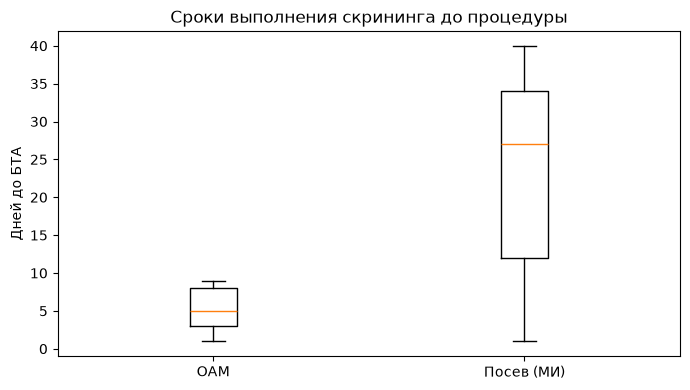

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
pair = df.dropna(subset=["oam_to_bta_days", "mi_to_bta_days"])
ax.boxplot([pair["oam_to_bta_days"], pair["mi_to_bta_days"]],
           tick_labels=["ОАМ", "Посев (МИ)"])
ax.set_ylabel("Дней до БТА")
ax.set_title("Сроки выполнения скрининга до процедуры")
plt.tight_layout(); plt.show()

%% [markdown]
## 4. Диссоциация ОАМ и посева (McNemar)
Главная клиническая находка: ОАМ систематически пропускает рост,
выявляемый посевом.

In [14]:
# %%
mc = res.mcnemar
print(f"Пар с обоими тестами: {mc['n_pairs']}")
print(f"ОАМ−/посев+ : {mc['oam_neg_mi_pos']}   (ОАМ пропустил рост)")
print(f"ОАМ+/посев− : {mc['oam_pos_mi_neg']}")
print(f"McNemar exact p = {mc['p_value']:.4g}")
print(mc["discordance_note"])

Пар с обоими тестами: 45
ОАМ−/посев+ : 20   (ОАМ пропустил рост)
ОАМ+/посев− : 0
McNemar exact p = 1.907e-06
ОАМ пропустил рост в 20 из 45 случаев положительного посева


In [15]:
ct = pd.DataFrame(mc["table"],
                  index=["ОАМ+", "ОАМ−"], columns=["посев+", "посев−"])
ct

,посев+,посев−
ОАМ+,25,20
ОАМ−,0,0


%% [markdown]
## 5. Первичная конечная точка — частота ИМВП за 5 суток
Сравниваем три способа оценки доли: Wilson, точный (Clopper-Pearson),
байесовский. При малом числе событий байес честнее.

In [16]:
# %%
p = res.primary
for label, key in [("Wilson", "uti_rate_wilson"), ("Clopper-Pearson", "uti_rate_exact")]:
    r = p[key]
    print(f"{label:16s}: {r['point']:.1%}  CI95 [{r['ci_low']:.1%}; {r['ci_high']:.1%}]")
b = p["uti_rate_bayes"]
print(f"{'Bayes Beta(1,1)':16s}: {b['posterior_mean']:.1%}  HDI95 [{b['hdi_low']:.1%}; {b['hdi_high']:.1%}]")
print()
print(stats.power_warning(p["uti_events"], p["n_evaluable"]))

Wilson          : 3.9%  CI95 [1.1%; 13.2%]
Clopper-Pearson : 3.9%  CI95 [0.5%; 13.5%]
Bayes Beta(1,1) : 5.7%  HDI95 [0.6%; 11.8%]

Всего 2 событий на 51 наблюдений — статистическая мощность критически низкая. Незначимые p-value НЕ означают отсутствия эффекта; направления трактуются как гипотезы.


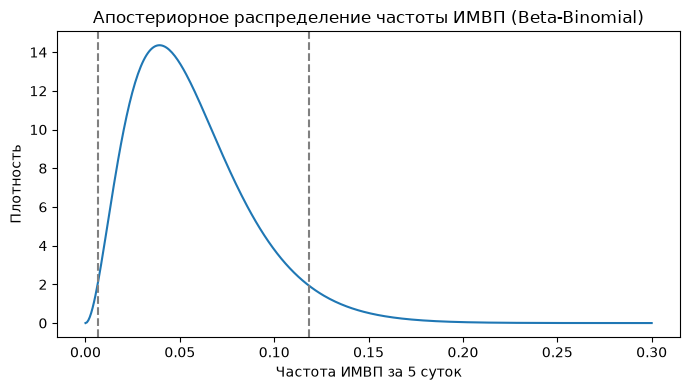

In [17]:
# %%
# Визуализация апостериорного распределения доли ИМВП
from scipy import stats as sps
a_post = 1 + p["uti_events"]
b_post = 1 + (p["n_evaluable"] - p["uti_events"])
xs = np.linspace(0, 0.3, 400)
plt.figure(figsize=(7, 4))
plt.plot(xs, sps.beta(a_post, b_post).pdf(xs))
plt.axvline(b["hdi_low"], ls="--", c="gray")
plt.axvline(b["hdi_high"], ls="--", c="gray")
plt.title("Апостериорное распределение частоты ИМВП (Beta-Binomial)")
plt.xlabel("Частота ИМВП за 5 суток"); plt.ylabel("Плотность")
plt.tight_layout(); plt.show()

%% [markdown]
## 6. Факторы и исход (Fisher) — строго как гипотезы
Все ассоциации при таком числе событий статистически незначимы;
направления интерпретируем осторожно.

In [18]:
# %%
fisher_df = pd.DataFrame([
    {"factor": k, "OR": v["odds_ratio"], "p": v["p_value"], "n": v["n"]}
    for k, v in res.fisher.items()
])
fisher_df

,factor,OR,p,n
0,any_prophylaxis,0.088889,0.188235,51
1,resistant_noted,0.000000,1.000000,51
2,significant_bacteriuria,0.000000,0.499608,51


%% [markdown]
## 7. Динамика микрофлоры у повторных пациентов

In [19]:
# %%
res.repeat

,patient,date,prev_organisms,cur_organisms,change
0,БОБРОВ,2025-08-24,Escherichia coli,Acinetobacter baumannii;Escherichia coli,acquisition
1,ВОЕВОДИН,2025-11-13,—,Acinetobacter baumannii,appearance
2,ВОРОНЧИХИН,2025-11-04,Acinetobacter baumannii,Acinetobacter baumannii,persistence
3,ГУСЕВ,2025-09-29,Proteus mirabilis,Proteus mirabilis,persistence
4,КУРГУЗОВА,2026-02-16,Enterococcus faecalis,Enterococcus faecalis;Proteus mirabilis,acquisition
5,ЛАПШИН,2026-01-15,—,Proteus mirabilis,appearance
6,ЛОСЕВА,2025-07-21,Enterococcus faecalis;Klebsiella pneumoniae,Enterococcus faecalis,partial_loss
7,НОСОВ,2025-10-11,—,—,persistence
8,ТУМАНОВ,2025-12-24,—,—,persistence
9,ФОМИНА,2025-08-22,Serratia marcescens,Serratia marcescens,persistence


%% [markdown]
## 8. Что даёт такой пайплайн
- Любое изменение протокола (`config/protocol.yaml`) перепроливает весь
  анализ — без правок в коде.
- Отчёт, слайды и этот ноутбук берут числа из ОДНОГО объекта `res`.
- Артефакты данных ловятся тестами и схемой, а не глазами по ходу.